In [161]:
#imports
from datetime import datetime
from operator import index
from random import random
import random
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow.keras.models import (Sequential, load_model, Model)
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import (Dense, Dropout, Conv1D, GRU, Bidirectional, LSTM, Flatten, Input, concatenate)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)
from sklearn.metrics import (r2_score, mean_absolute_error)
from math import ceil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [162]:
# Daten einlesen
df = pd.read_csv('../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv')

In [163]:
# Zeiteigenschaften setzen und Index machen
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H:%M:%S')
df = df.set_index('time')

In [164]:
#df.sort_index(inplace=True)

In [165]:
# Netz mit Generator
bruecken = df.columns.values
#df["target"]=df['bruehler_straße'].shift(-1)
X = df[bruecken].values
y = df[[bruecken[0]]].values
split = ceil(len(df)* 0.8)
time_train_gesamt = df.index
time_train = df[:split].index
time_test = df[split:].index
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]
X_train.shape, X_test.shape, y_train.shape, y_test.shape
#df.dropna(inplace=True)
#df.isna().sum()

((55796, 9), (13949, 9), (55796, 1), (13949, 1))

In [166]:
scaler_x = StandardScaler()
scaler_x.fit(X_train)
X_train = scaler_x.transform(X_train)
X_test = scaler_x.transform(X_test)
scaler_y = StandardScaler()
scaler_y.fit(y_train)
y_train = scaler_y.transform(y_train)
y_test = scaler_y.transform(y_test)

In [167]:
week_means = pd.DataFrame(X, index=time_train_gesamt, columns=bruecken)
week_means = week_means.groupby(week_means.index.isocalendar().week)[week_means.columns].mean()
week_means

,bruehler_straße,estermannufer,kennedybruecke,nordbruecke,suedbruecke,rhenusallee,von_sandt_ufer,weg_auf_dem_damm,wilhelm_spiritus_ufer
week,,,,,,,,,
1,24.444728,20.829082,209.364796,37.896259,73.471088,62.532313,53.074830,63.185374,74.998299
2,26.488562,18.570261,222.387255,35.992647,69.584150,54.606209,48.876634,58.697712,70.214869
3,25.270089,8.333333,219.068452,25.993304,68.594494,35.420387,28.700893,40.149554,53.796131
4,25.574405,8.572173,213.601190,26.569196,69.115327,34.738095,26.722470,39.639137,49.059524
5,26.573661,11.991071,216.764137,30.656994,76.375000,44.755208,35.826637,47.212054,60.295387
6,33.798363,26.197917,272.352679,46.122024,95.307292,78.014137,66.868304,78.034226,96.848214
7,27.395089,14.705357,229.733631,34.795387,80.210565,49.406994,41.747024,57.250000,64.456101
8,27.200149,15.608631,235.552083,36.002976,84.470238,51.636905,43.422619,59.043155,67.239583
9,27.467262,15.754464,239.721726,34.633929,81.018601,50.101190,42.086310,55.078869,66.180060


In [168]:
def data_generator_seasonal(X: np.array, y: np.array, mean_tab: pd.DataFrame, y_index: pd.Index, window=144, horizon=24, season=14, batch_size=1, epochs=10):
    for epoch in range(epochs):
        X_s, X_m, y_ = [], [], []
        batch_counter = 0
        last_val = len(X) - (window + horizon)
        index_range = list(range(last_val))
        random.shuffle(index_range)
        for idx in index_range:
            season_range = range(window+idx-1, idx-1, -season)
            X_s.append([X[i] for i in season_range])
            y_date = y_index[idx+window+horizon]
            y_mean = mean_tab.loc[y_date.week]
            X_m.append(y_mean.values)
            y_.append(y[idx+window+horizon])
            batch_counter += 1
            if (batch_counter == batch_size or index_range[-1] == idx):
                yield ((np.array(X_s), np.array(X_m)), np.array(y_))
                X_s, X_m, y_ = [], [], []
                batch_counter = 0

test_gen = data_generator_seasonal(X_train, y_train, mean_tab=week_means, y_index=time_train)
(x_s, x_m), y_ = next(test_gen)
print(x_s.shape, x_m.shape, y_.shape)

(1, 11, 9) (1, 9) (1, 1)


In [169]:
batch_size = 128
epochs = 100
window = 144
horizon = 24
indicators = 9
num_seasons = 12
reg = l2(0.0001)

input_sn = Input(shape=(num_seasons, indicators), name='in_sn')
input_mn = Input(shape=(indicators,), name='in_mn')

sn = GRU(units=32, dropout=0.3, go_backwards=True, kernel_regularizer=reg, name='sn_gru')(input_sn)
mn = Dense(units=indicators, activation='tanh', kernel_regularizer=reg)(input_mn)
mn = Dropout(0.2)(mn)
comp = concatenate([sn, mn], axis=-1)
comp = Dense(units=1, kernel_regularizer=reg)(comp)

model_seasonal = Model([input_sn, input_mn], comp)
model_seasonal.compile(loss='mse', optimizer='adam', metrics=['mae'])

In [170]:
gen_train_seasonal = data_generator_seasonal(X_train, y_train, mean_tab=week_means, y_index=time_train, window=window, horizon=horizon, season=num_seasons, batch_size=batch_size, epochs=epochs)
gen_test_seasonal = data_generator_seasonal(X_test, y_test, mean_tab=week_means, y_index=time_test, window=window, horizon=horizon, season=num_seasons, batch_size=batch_size, epochs=epochs)

early = EarlyStopping(monitor='val_loss', patience=10)
check = ModelCheckpoint(filepath='Gesamt_model.keras', monitor='val_loss', save_best_only=True)

steps_train = ceil(len(X_train-(window+horizon))/batch_size)
steps_test = ceil(len(X_test-(window+horizon))/batch_size)

history_seasonal = model_seasonal.fit(gen_train_seasonal, epochs=epochs, steps_per_epoch=steps_train, validation_data=(gen_test_seasonal), validation_steps=steps_test, callbacks=[early, check])
#history_seasonal = model_seasonal.fit(X_train, epochs=epochs, steps_per_epoch=steps_train, validation_data=X_test, validation_steps=steps_test, callbacks=[early, check])

Epoch 1/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.6865 - mae: 0.6192 - val_loss: 0.7324 - val_mae: 0.5141
Epoch 2/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4803 - mae: 0.4906 - val_loss: 0.7680 - val_mae: 0.5266
Epoch 3/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4406 - mae: 0.4625 - val_loss: 0.7257 - val_mae: 0.5096
Epoch 4/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4220 - mae: 0.4507 - val_loss: 0.7226 - val_mae: 0.5071
Epoch 5/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4049 - mae: 0.4395 - val_loss: 0.7404 - val_mae: 0.5111
Epoch 6/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3931 - mae: 0.4321 - val_loss: 0.7310 - val_mae: 0.5126
Epoch 7/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3792 - mae: 0.4247 - val_loss: 0.6575 - val_mae: 0.5062
Epoch 8/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3773 - mae: 0.4207 - val_loss: 0.7183 - val_mae: 0.5177
Epoch 9/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/

Text(0, 0.5, 'loss')

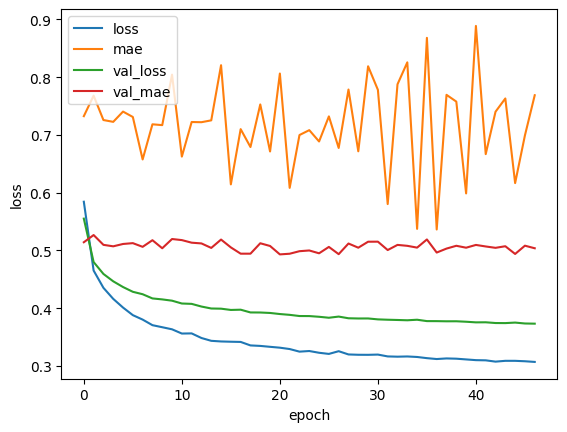

In [171]:
plt.plot(history_seasonal.history['loss'])
plt.plot(history_seasonal.history['val_loss'])
plt.plot(history_seasonal.history['mae'])
plt.plot(history_seasonal.history['val_mae'])
plt.legend(['loss', 'mae', 'val_loss', 'val_mae'])
plt.xlabel('epoch')
plt.ylabel('loss')

In [172]:
model_seasonal.summary()

Model: "functional_47"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ in_mn (InputLayer)  │ (None, 9)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ in_sn (InputLayer)  │ (None, 12, 9)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 9)         │         90 │ in_mn[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sn_gru (GRU)        │ (None, 32)        │      4,128 │ in_sn[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 9)         │          0 │ dense_20[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 41)        │          0 │ sn_gru[0][0],     │
│ (Concatenate)       │                   │            │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 1)         │         42 │ concatenate_7[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,782 (49.93 KB)

 Trainable params: 4,260 (16.64 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,522 (33.29 KB)

In [173]:
loss, acc = model_seasonal.evaluate(gen_test_seasonal, steps=steps_test)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5645 - mae: 0.4965


In [174]:
def data_generator(X, y, window=144, horizon=24, batch_size=1, epochs=10):
    for epoch in range(epochs):
        X_temp = []
        y_temp = []
        batch_counter = 0
        last_val = len(X) - (window + horizon)
        index_range = list(range(last_val))
        random.shuffle(index_range)
        for idx in index_range:
            X_idx = X[idx:idx+window]
            y_idx = y[idx+window+horizon]
            X_temp.append(X_idx)
            y_temp.append(y_idx)
            batch_counter += 1
            if (batch_counter == batch_size or index_range[-1] == idx):
                yield np.array(X_temp), np.array(y_temp).reshape(-1)
                X_temp = []
                y_temp = []
                batch_counter = 0

In [175]:
reg = l2(0.0001)
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=6, input_shape=(144, 9), activation='relu'))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(units=32,dropout=0.3,kernel_regularizer=reg)))
model.add(Dense(units=1, kernel_regularizer=reg))
model.compile(loss='mse', optimizer='adam', metrics=['mae'])

/home/leonidas/Uni/Semester_5_24_25/Datenanalyse/Projekt/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [176]:
batch_size = 128
epochs = 50
window = 144
horizon = 24

gen_train = data_generator(X_train, y_train, batch_size=batch_size, epochs=epochs)
gen_test = data_generator(X_test, y_test, batch_size=batch_size, epochs=epochs)

early = EarlyStopping(monitor='val_loss', patience=10)
check = ModelCheckpoint(filepath='Conv1D.keras', monitor='val_loss', save_best_only=True)

steps_train = ceil(len(X_train-(window+horizon))/batch_size)
steps_test = ceil(len(X_test-(window+horizon))/batch_size)

historyConv1D = model.fit(gen_train, epochs=epochs, steps_per_epoch=steps_train, validation_data=(gen_test), validation_steps=steps_test, callbacks=[early, check])
#historyConv1D = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, steps_per_epoch=steps_train, validation_split=0.1, shuffle=1, validation_steps=steps_test, callbacks=[early, check])


Epoch 1/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.5368 - mae: 0.5155 - val_loss: 0.6484 - val_mae: 0.4798
Epoch 2/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.3659 - mae: 0.4067 - val_loss: 0.6488 - val_mae: 0.4824
Epoch 3/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - loss: 0.3484 - mae: 0.3886 - val_loss: 0.7325 - val_mae: 0.4987
Epoch 4/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.3472 - mae: 0.3873 - val_loss: 0.5873 - val_mae: 0.4813
Epoch 5/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - loss: 0.3356 - mae: 0.3796 - val_loss: 0.6811 - val_mae: 0.5004
Epoch 6/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 0.3322 - mae: 0.3785 - val_loss: 0.6699 - val_mae: 0.4962
Epoch 7/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 0.3138 - mae: 0.3674 - val_loss: 0.6661 - val_mae: 0.4938
Epoch 8/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - loss: 0.3093 - mae: 0.3626 - val_loss: 0.6547 - val_mae: 0.4832
Epoch 9/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 

In [177]:
def predictions_vs_true(X_pred, y_true, model, scaler, window=144, horizon=24):
    X_temp=[]
    y_temp=[]
    y_temp_simple=[]
    num_pred = len(X_pred)-(window+horizon)
    for idx in range(num_pred):
        X_idx = X_pred[idx:idx+window]
        y_idx = y_true[idx+window+horizon]
        X_temp.append(X_idx)
        y_temp.append(y_idx)
        y_temp_simple.append(y_true[idx+window])
    X_temp = np.array(X_temp)
    y_pred = model.predict(X_temp)
    y_pred = scaler.inverse_transform(y_pred)
    y_temp = scaler.inverse_transform(y_temp)
    y_temp_simple = scaler.inverse_transform(y_temp_simple)
    return y_temp, y_pred, y_temp_simple

In [178]:
model = load_model('Conv1D.keras')
y_true, y_pred, y_simple = predictions_vs_true(X_test, y_test, model=model, scaler = scaler_y)

print('mae, predictions', mean_absolute_error(y_true, y_pred))
print('mae, simple pred', mean_absolute_error(y_simple, y_simple))

431/431 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
mae, predictions 15.50511720061509
mae, simple pred 0.0


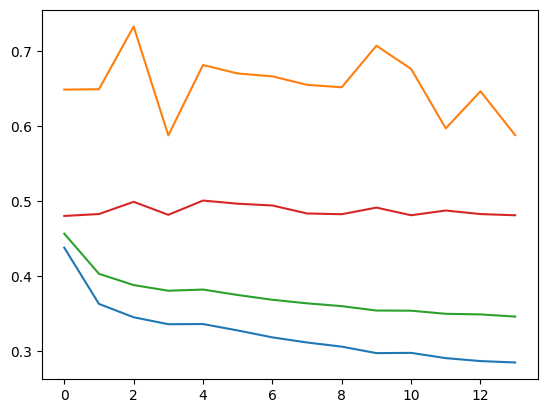

In [179]:
plt.plot(historyConv1D.history['loss'])
plt.plot(historyConv1D.history['val_loss'])
plt.plot(historyConv1D.history['mae'])
plt.plot(historyConv1D.history['val_mae'])

In [180]:
y_pred = model.predict(X_test)


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None